# Visualización de datos

### Ejercicio 1
En éste ejercicio utilizamos los datos del fucking gapmider de mierda (recordar el ejercicio 10 de la práctica 2 (yo me acuerdo muy bien))

In [3]:
import pandas as pd
import seaborn.objects as so


In [4]:
url = "https://raw.githubusercontent.com/resbaz/r-novice-gapminder-files/master/data/gapminder-FiveYearData.csv"
gapminder = pd.read_csv(url)

(a) Utilizando _seaborn.objects_ , graficar la curva de la expectativa de vida en Argentina en función del año, completando el siguiente código. Sugerencia : Recordar de la práctica anterior cómo filtrar datos de un dataset.

In [5]:
datosArgentina =gapminder[gapminder['country'] == 'Argentina']
datosArgentina

,country,year,pop,continent,lifeExp,gdpPercap
48,Argentina,1952,17876956.0,Americas,62.485,5911.315053
49,Argentina,1957,19610538.0,Americas,64.399,6856.856212
50,Argentina,1962,21283783.0,Americas,65.142,7133.166023
51,Argentina,1967,22934225.0,Americas,65.634,8052.953021
52,Argentina,1972,24779799.0,Americas,67.065,9443.038526
53,Argentina,1977,26983828.0,Americas,68.481,10079.026740
54,Argentina,1982,29341374.0,Americas,69.942,8997.897412
55,Argentina,1987,31620918.0,Americas,70.774,9139.671389
56,Argentina,1992,33958947.0,Americas,71.868,9308.418710
57,Argentina,1997,36203463.0,Americas,73.275,10967.281950


(b)Realizar un nuevo gráfico donde puedan verse las curvas de la expectativa de vida de los países de América en función del año, una curva por cada país.

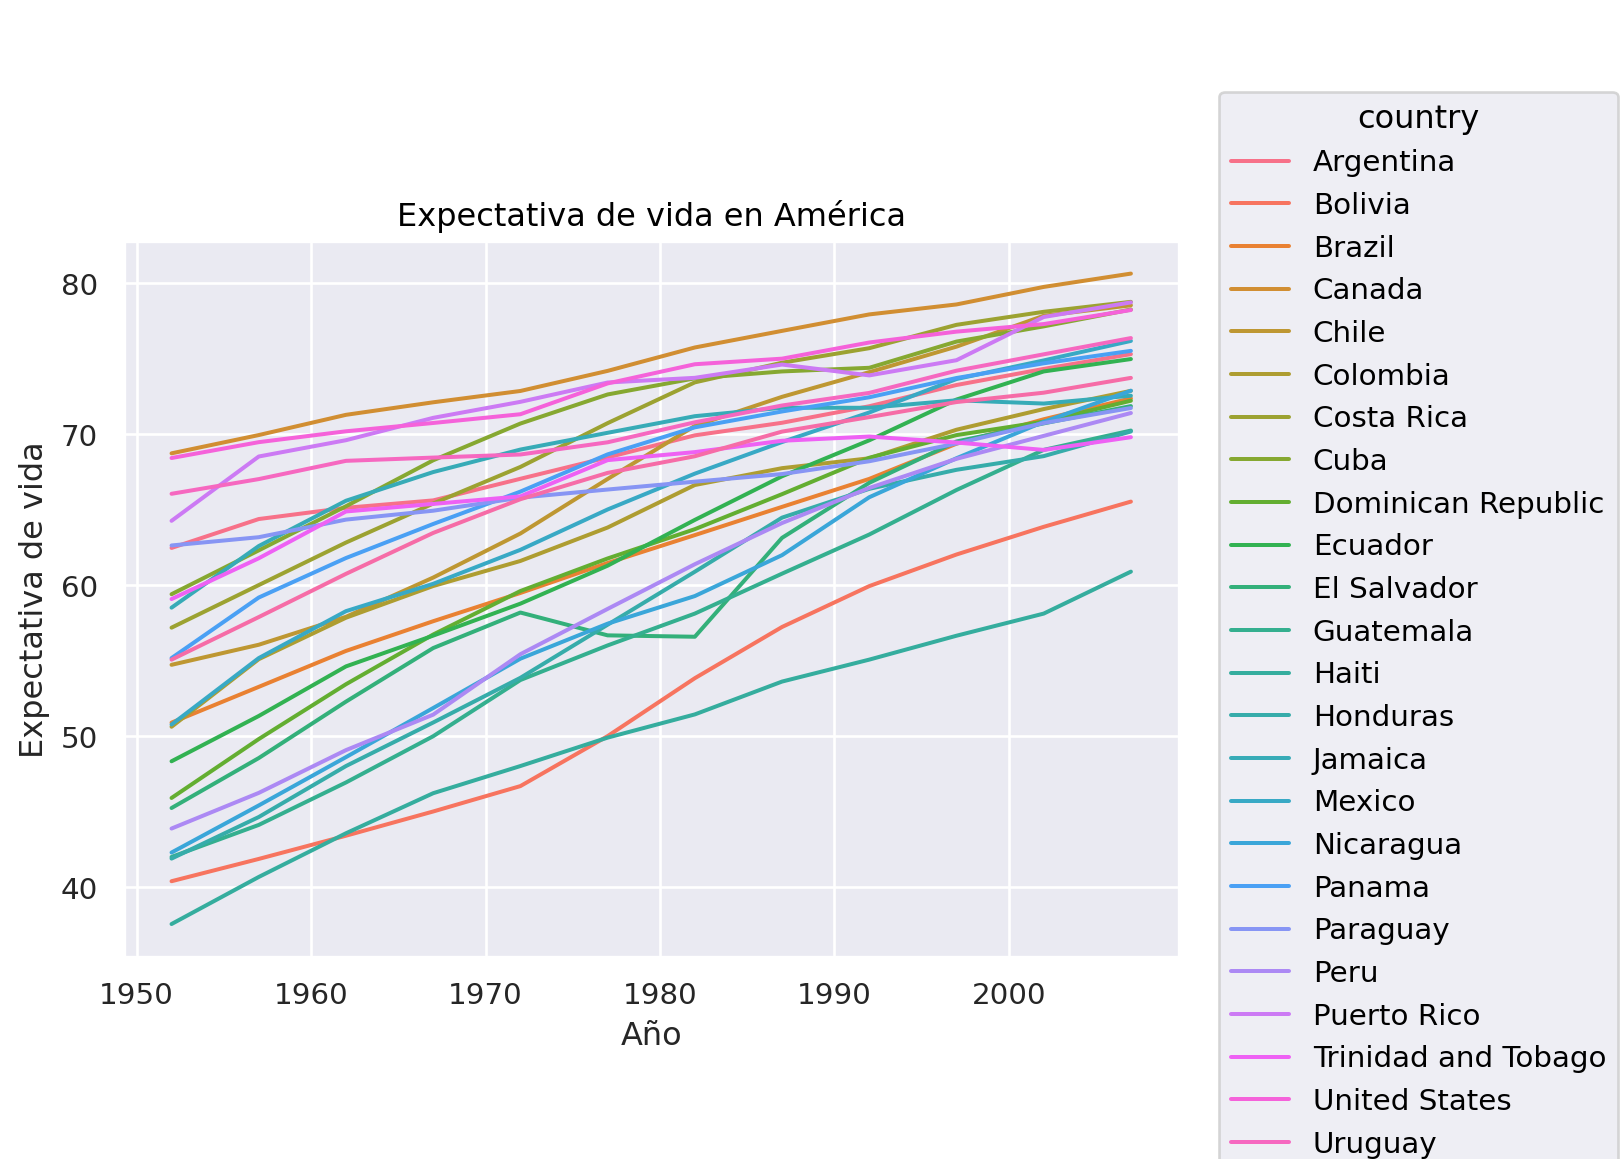

In [6]:
datosAmerica = gapminder[gapminder['continent']== 'Americas']
(    so.Plot(data=datosAmerica, x='year', y='lifeExp', color='country')
    .add(so.Line())
    .label(title='Expectativa de vida en América', x='Año', y='Expectativa de vida')
)

(c) Queremos agregar al gráfico del item anterior una curva de tendencia lineal utilizando el método .add(so.Line(),so.PolyFit(1)) ¿ Cuál de las siguientes dos formas de agrupar los datos es la forma correcta? . Explicar la diferencia

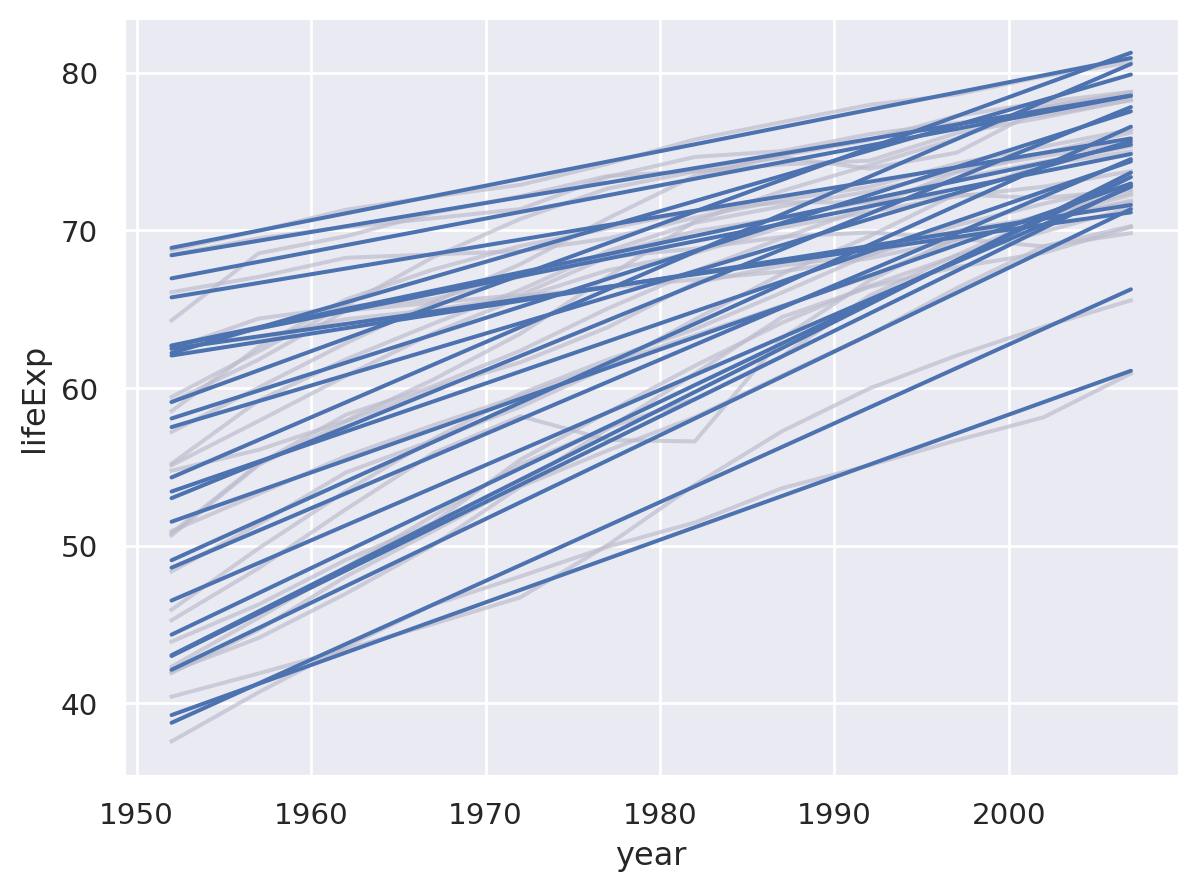

In [7]:
(
    so.Plot(data = datosAmerica, x = 'year',y ='lifeExp',group = 'country')
    .add(so.Lines(color="#bbca"))
    .add(so.Line(),so.PolyFit(1))
)
# Éste código hace un ajuste de regresión lineal a todos los datos juntos, sin importar el país al que correspondan. Es decir, hace un ajuste de regresión lineal a todos los puntos del gráfico, sin importar a qué país correspondan.

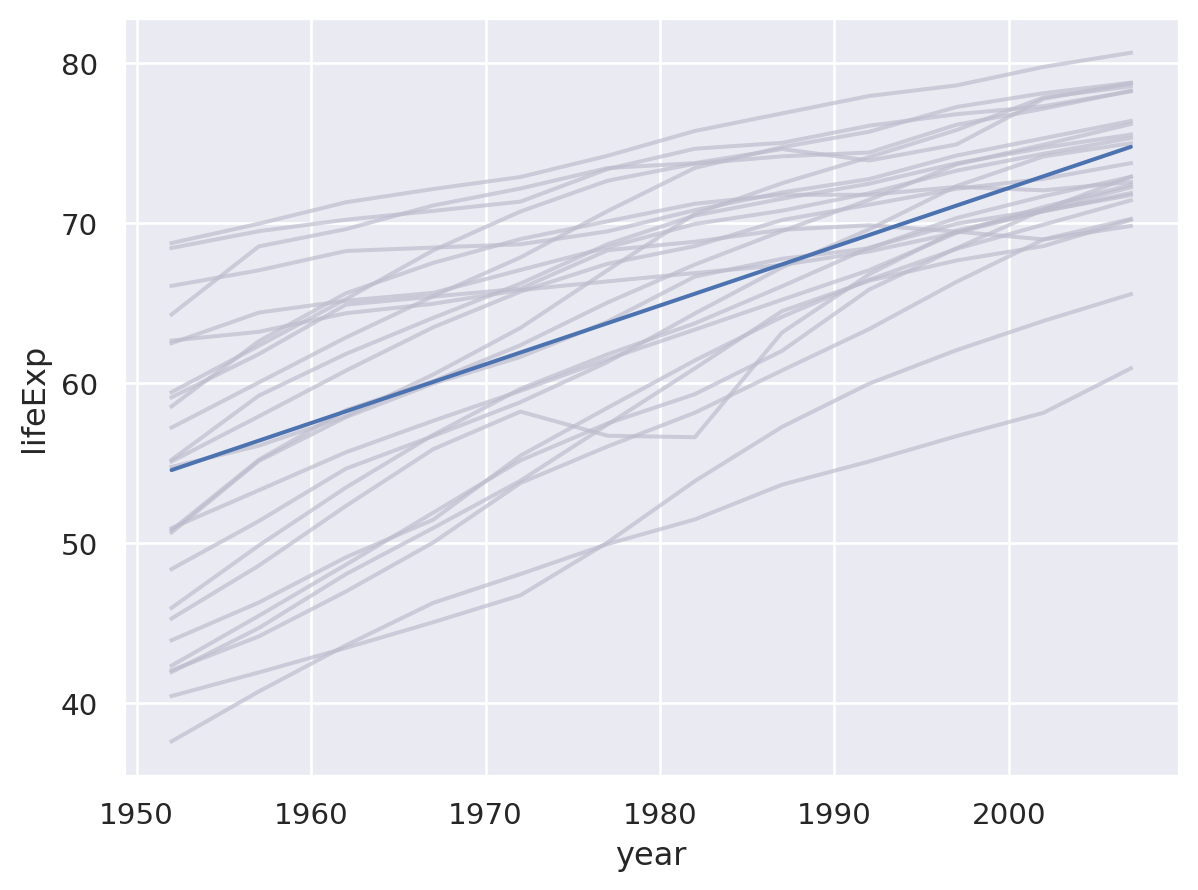

In [8]:
(
    so.Plot(data = datosAmerica, x = 'year',y ='lifeExp')
    .add(so.Lines(color="#bbca"), group = 'country')
    .add(so.Line(),so.PolyFit(1))
)

# Éste código , a diferencia del anterior, hace un ajuste de regresión lineal a cada país, en vez de a todos los datos juntos.

La correcta es la segunda opción, que muestra como evoluciona le expectativa de vida en los distintos países del dataset con el pasar del tiempo.

La primera opción, hace una regresión lineal por cada país, lo cual termina en un gráfico confuso.

(d) Realizar el siguiente gráfico, con las curvas de expectativa de vida agrupadas por continente. Basándose en el código del ítem (c), completar el siguiente código.

In [9]:
gapContinents =gapminder.groupby('continent')
gapContinents.groups.keys()
gapContinents.get_group('Americas')

,country,year,pop,continent,lifeExp,gdpPercap
48,Argentina,1952,17876956.0,Americas,62.485,5911.315053
49,Argentina,1957,19610538.0,Americas,64.399,6856.856212
50,Argentina,1962,21283783.0,Americas,65.142,7133.166023
51,Argentina,1967,22934225.0,Americas,65.634,8052.953021
52,Argentina,1972,24779799.0,Americas,67.065,9443.038526
...,...,...,...,...,...,...
1639,Venezuela,1987,17910182.0,Americas,70.190,9883.584648
1640,Venezuela,1992,20265563.0,Americas,71.150,10733.926310
1641,Venezuela,1997,22374398.0,Americas,72.146,10165.495180
1642,Venezuela,2002,24287670.0,Americas,72.766,8605.047831


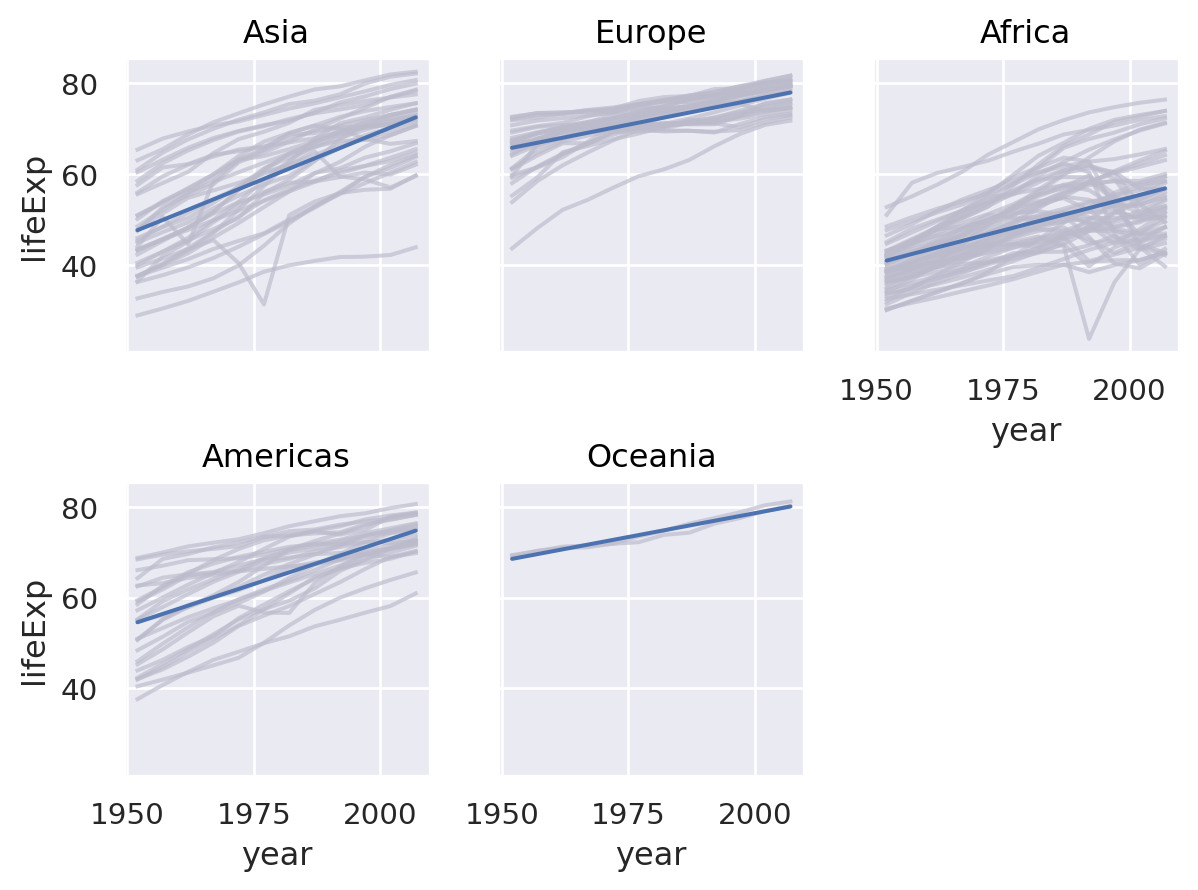

In [10]:
(
    so.Plot(data = gapminder, x = 'year',y ='lifeExp')
    .add(so.Lines(color="#bbca"), group = 'country')
    .add(so.Line(),so.PolyFit(1))
    .facet("continent",wrap=3)
)

facet() crea múltiples gráficos individuales basados en una variable categórica (en éste caso el continente).

El parámetro wrap indica cuántos gráficos vamos a poner en cada fila.

### Ejercicio 2
En los siguientes ejercicios vamos a trabajar con el dataset _penguins_ disponible en la biblioteca _seaborn_ ¿Cuantas filas y columnas hay en el dataset penguins?

In [11]:
import seaborn as sns
penguins = sns.load_dataset("penguins")

### Ejercicio 3
Como vimos en el ejercicio 1(c) , si asignamos una codificación (o mapeo) al definir un Plot(), el mapeo se asigna en todas las capas de marcas (objetos mark). En cambio, si asignamos una codificación dentro del método add() de una marca, el mapeo se realiza sólo en esa capa. Por último, so asignamos un parámetro de la marca, el valor se asigna directamente.

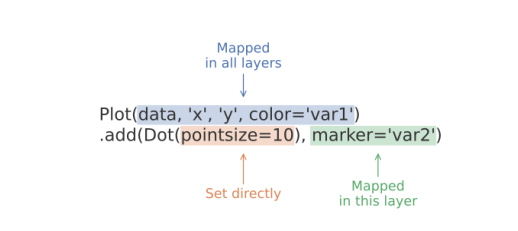

¿Qué resultado esperan para el siguiente gráfico?¿Cuáles codificaciones se pasan de Plot() a Dot() y cuales no pueden pasarse? ¿ Cuáles codificaciones se establecen en Dot()? ¿ Cuáles variables están asignadas directamente en Dot()? ¿De qué color van a pintarse los puntos?

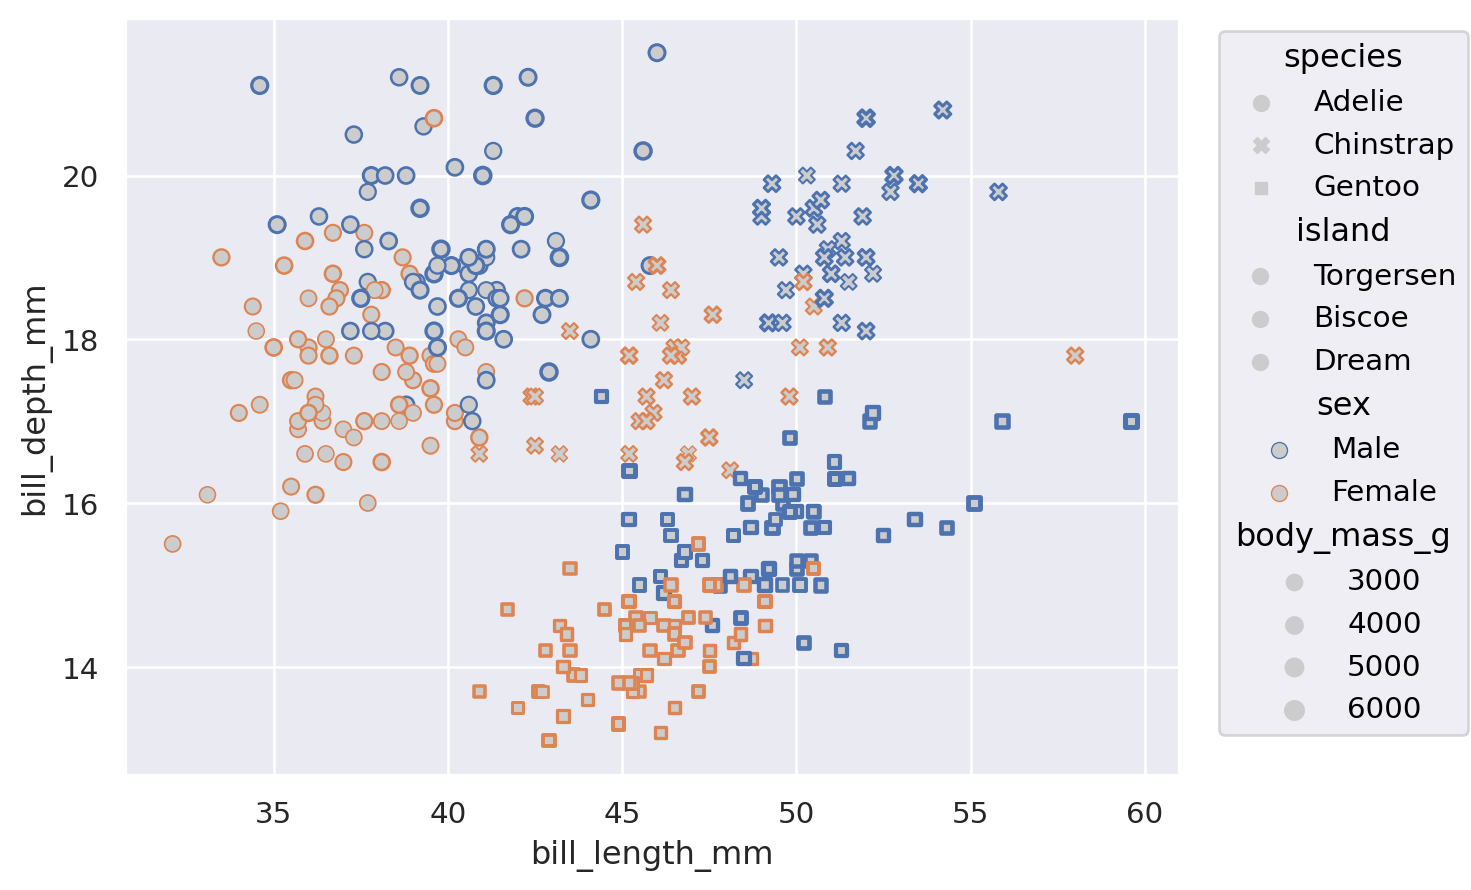

In [ ]:
(
    so.Plot(
        penguins, x = "bill_length_mm", y = "bill_depth_mm", marker = "species",
        linestyle = "island", color = "species"
    )
    .add(so.Dot(color=".8"),edgecolor="sex")
)

#Los parámetros de Plot que se podrían usar en Dot son marker, linestyle y color. En este caso, se ha usado marker para diferenciar las especies de pingüinos, linestyle para diferenciar el sexo de los pingüinos y color para diferenciar las especies de pingüinos. En otras palabras, los parámetros "estéticos". 

### Ejercicio 4
(a) Hacer un gráfico de dispersión de bill_depth_mm (en el eje x) vs bill_length_mm (en el eje y)

(b) ¿Distinguen grupos distintos de puntos en el gráfico? ¿ A qué puede deberse?

(c) Introducir alguna modificación en el gráfico anterior para verificar o refutar su conjetura del ítem anterior.

<Axes: xlabel='bill_length_mm', ylabel='bill_length_mm'>

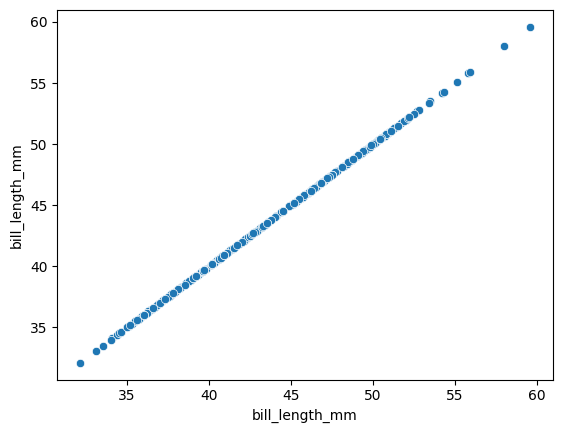

In [23]:
sns.scatterplot(data = penguins, x="bill_length_mm", y="bill_length_mm")

huh?

Está hecho así a propósito para responder la pregunta (b). Como vemos estamos comparando "bill_length_mm" contra "bill_length_mm". Lo que naturalmente nos va a dejar una recta de 45. Si no agregamos ningun cambio de estilo, ni cambiamos las variables de comparación, es indistinguible un grupo de puntos de cualquier otro.

<Axes: xlabel='bill_depth_mm', ylabel='bill_length_mm'>

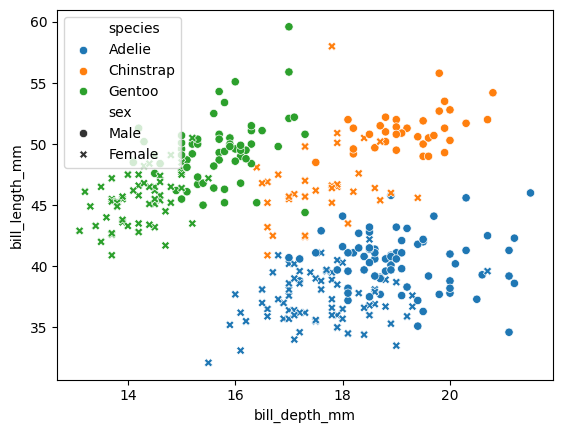

In [27]:
sns.scatterplot(data = penguins, x="bill_depth_mm", y="bill_length_mm", hue="species",style="sex")

Ésto es un avance, ahora también podemos distinguir tanto por especie(color) como por sexo (forma del punto)

Tambien podemos elegir otras variables para ver como queda

In [25]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


<Axes: xlabel='bill_length_mm', ylabel='flipper_length_mm'>

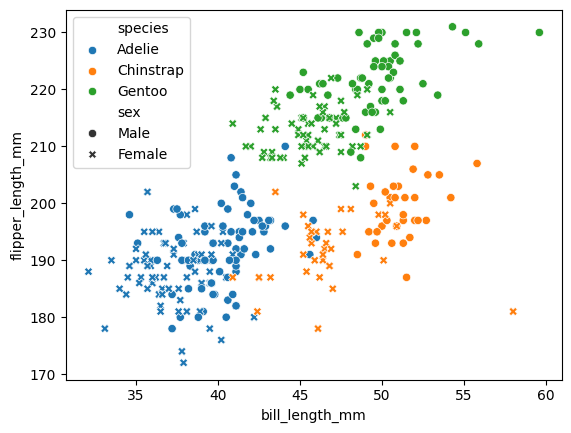

In [29]:
sns.scatterplot(data = penguins, x="bill_length_mm", y="flipper_length_mm", hue="species",style="sex")

<Axes: xlabel='bill_length_mm', ylabel='species'>

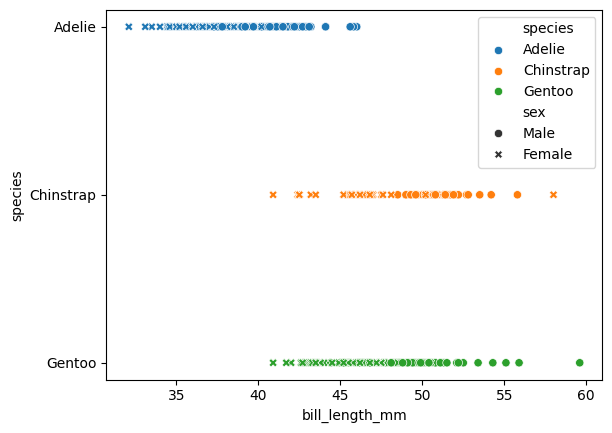

In [30]:
sns.scatterplot(data = penguins, x="bill_length_mm", y="species", hue="species",style="sex")

Quizá un scatterplot no sea lo mejor para graficar variables numéricas vs variables categóricas

<Axes: xlabel='bill_depth_mm', ylabel='body_mass_g'>

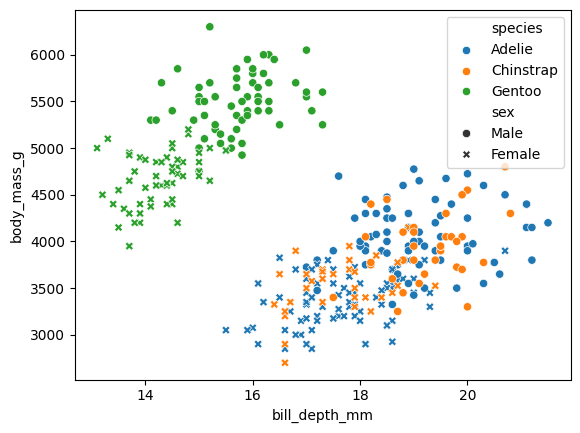

In [38]:
sns.scatterplot(data = penguins, x="bill_depth_mm", y="body_mass_g", hue="species",style="sex")

### Ejercicio 5
(a) rehacer el gráfico del ejercicio 4(a), coloreando los puntos según el sexo. ¿Qué se observa?

Ésto ya está hecho arriba

(b) Usando la función facet() separar el gráfico del item anterior en tres subgráficos, uno para cada especie

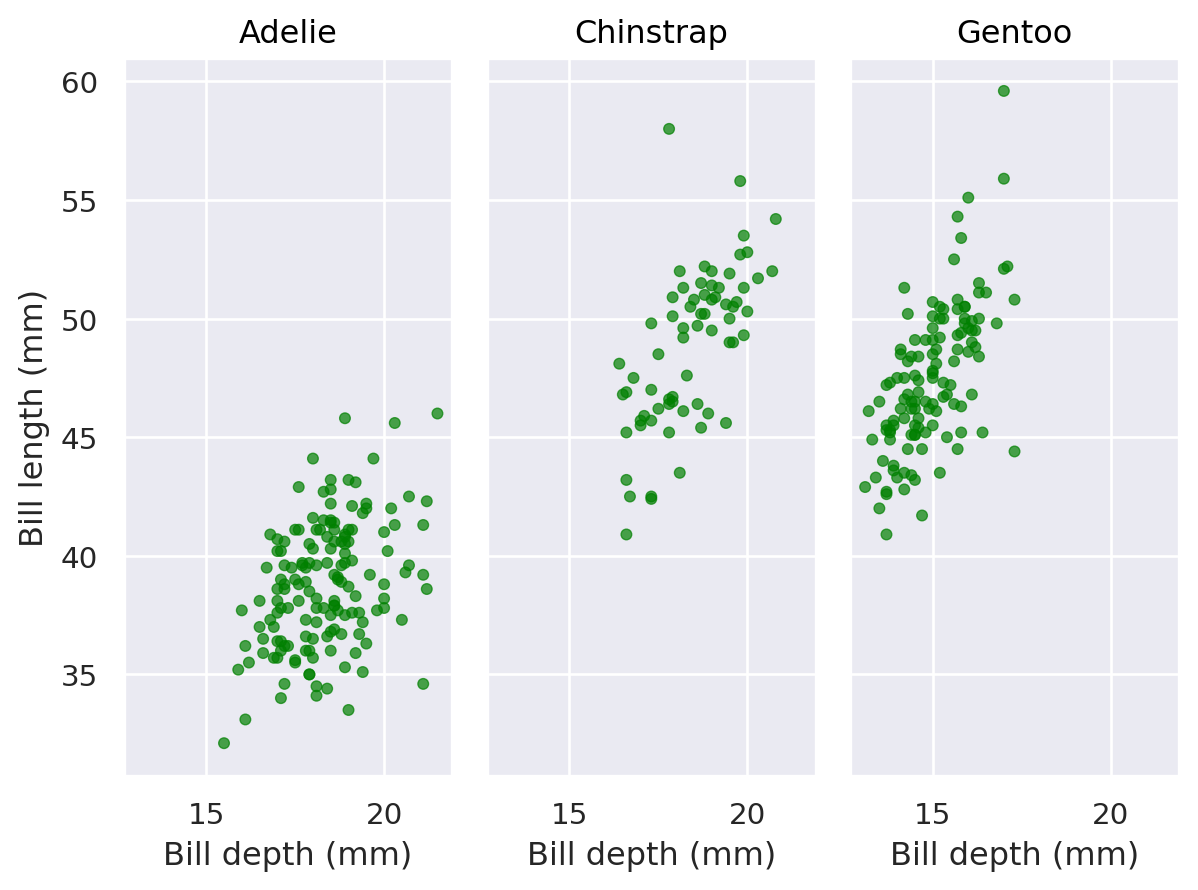

In [55]:

(
    so.Plot(data = penguins, x = 'bill_depth_mm',y ='bill_length_mm')
    .add(so.Dot(pointsize=4,alpha=0.7,color='green'), group = 'species')
    .facet("species",wrap=3)
        .label(
        x="Bill depth (mm)",
        y="Bill length (mm)",
        color="Sexo"
    )
)

### Ejercicio 6
(a) ¿Cuántos pinguinos se registraron en cada isla en la base de datos? Recordar los comandos groupby() y size() de la práctica anterior.

In [71]:
pinguTorgesen = penguins.groupby('island')
pinguTorgesen.size()

island
Biscoe       168
Dream        124
Torgersen     52
dtype: int64

lol pensé que iba a tener que hacer algo más

(b) Realizar un gráfico de barras con la cantidad de pinguinos en cada isla , completando el siguiente código

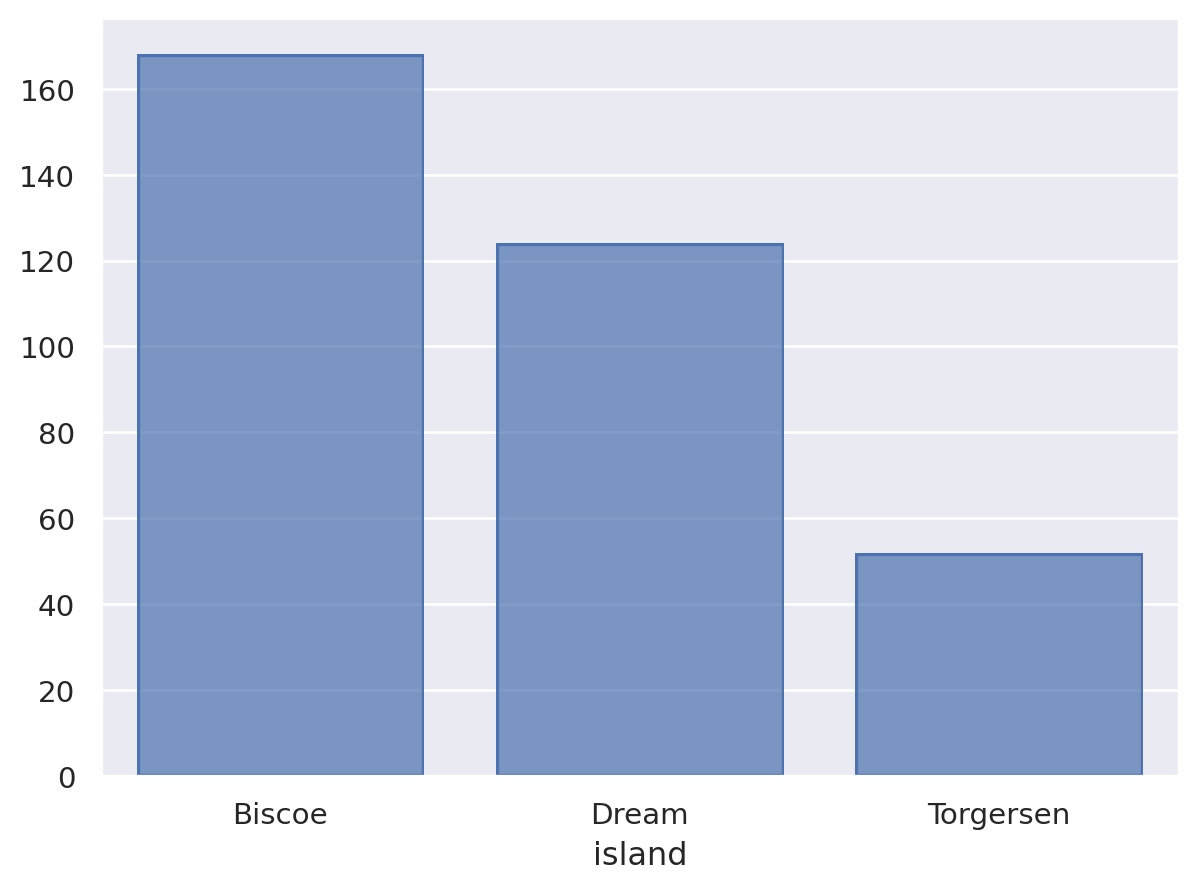

In [69]:
pinguinos_por_isla = penguins.groupby('island').size()
(
     so.Plot(x= pinguinos_por_isla.index , y = pinguinos_por_isla.values)
     .add(so.Bar())
)


(c) El gráfico que acabamos de hacer es un histograma categórico (usamos una variable categórica en el eje X). Podemos realizar el mismo gráfico usando la función Hist() para contar automáticamente las cantidades (sin tener que definir una variable pinguinos_por_isla). Completar el siguiente código.

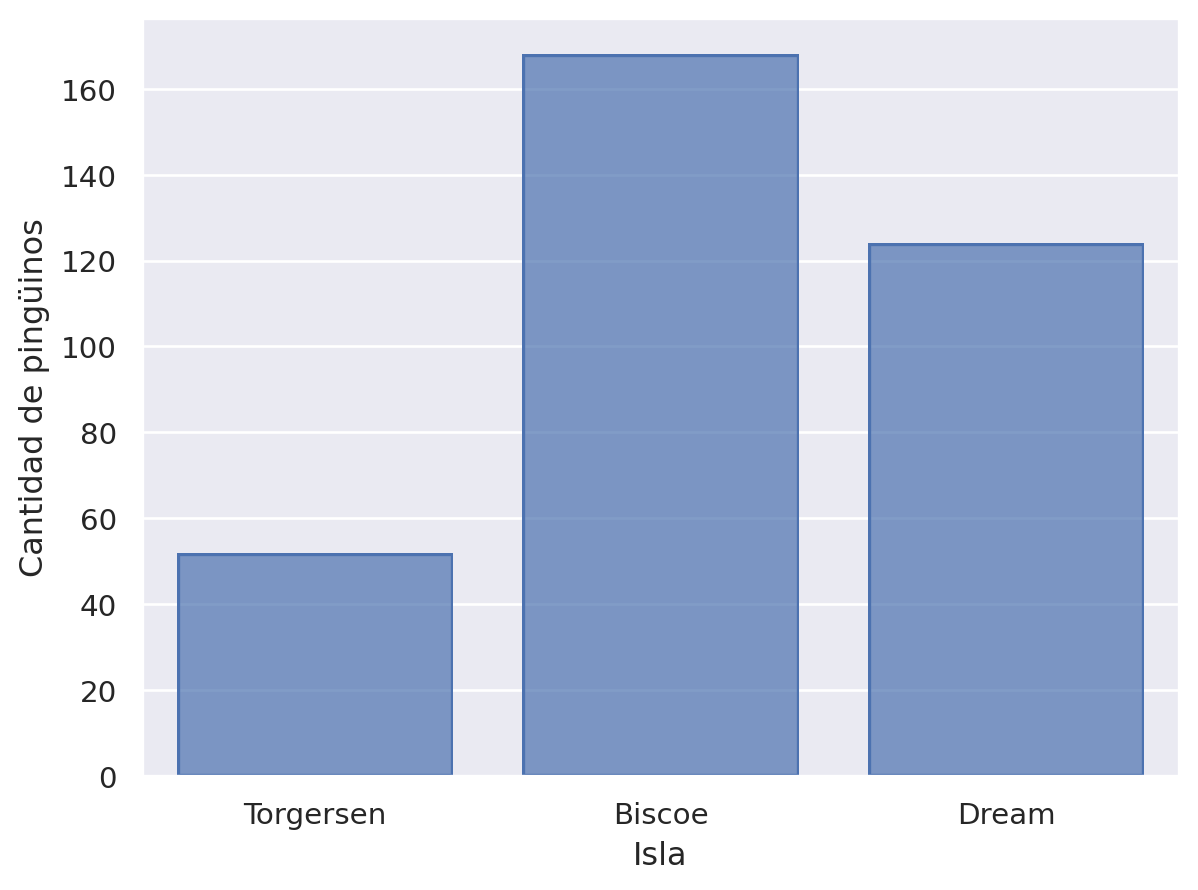

In [81]:
(
    so.Plot(data= penguins, x='island')
    .add(so.Bar(),so.Hist())
    .label(x="Isla", y="Cantidad de pingüinos")
)

(d) ¿Por qué no hace falta especificar ninguna variable y en el último gráfico?

El método Hist lo hace automáticamente ;)

(e) Queremos ver en un gráfico cuántos pinguinos de cada especie hay en cada isla, ¿Cómo podemos hacerlo? Si usan un gráfico de barras, pueden usar la función Dodge() para hacer barras distintas por categoría

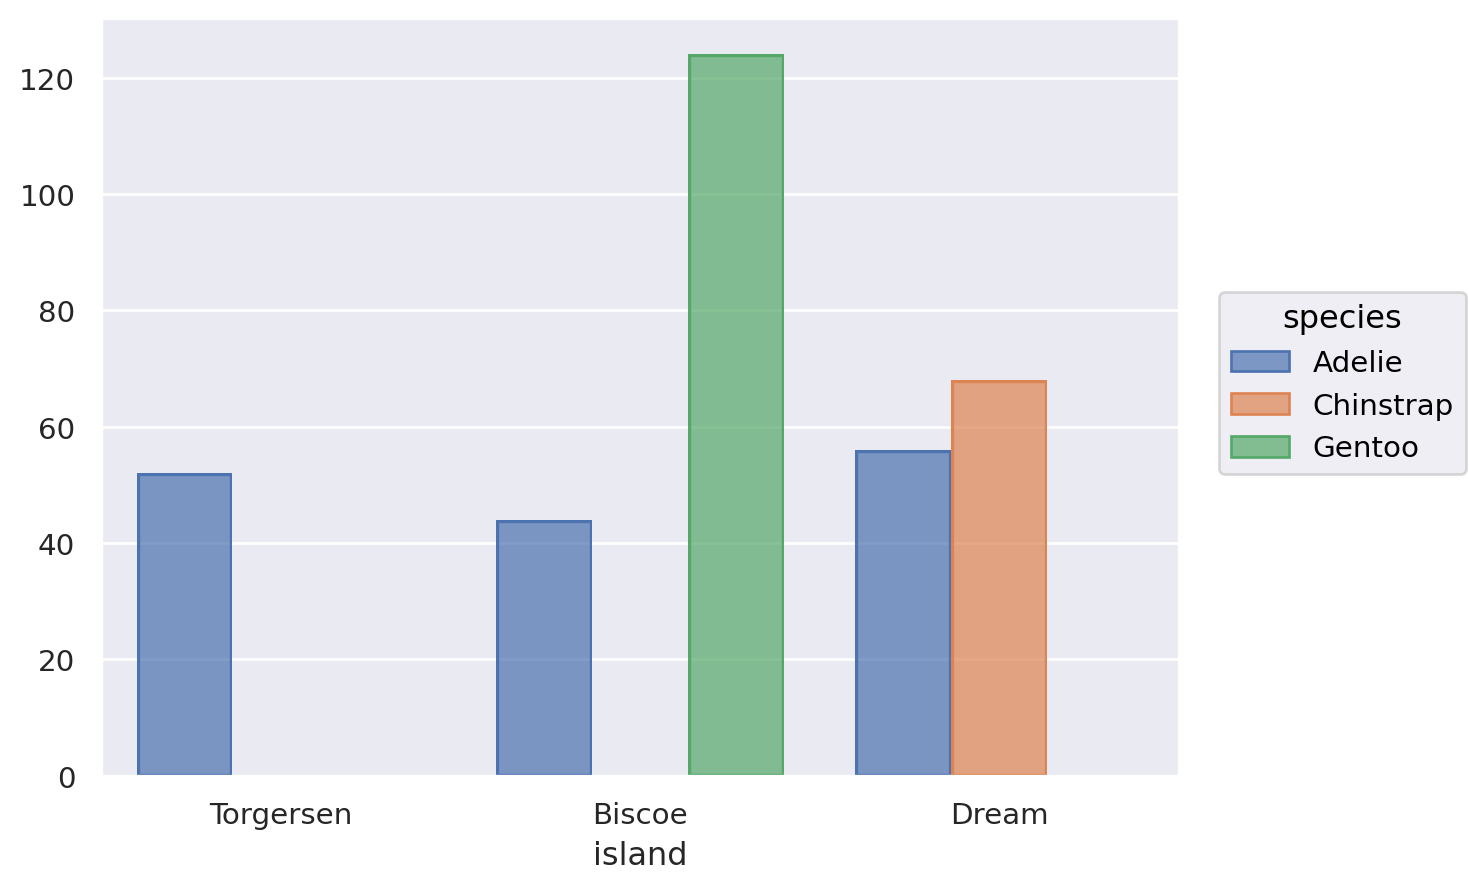

In [86]:
(
    so.Plot(data = penguins, x = 'island')
    .add(so.Bar(),so.Hist(),so.Dodge(),color='species')
)

#Si hacemos el mismo gráfico sin el so.Dodge() , las barras se superponen.

(f) ¿Cómo podrian visualizar lo mismo usando facet?

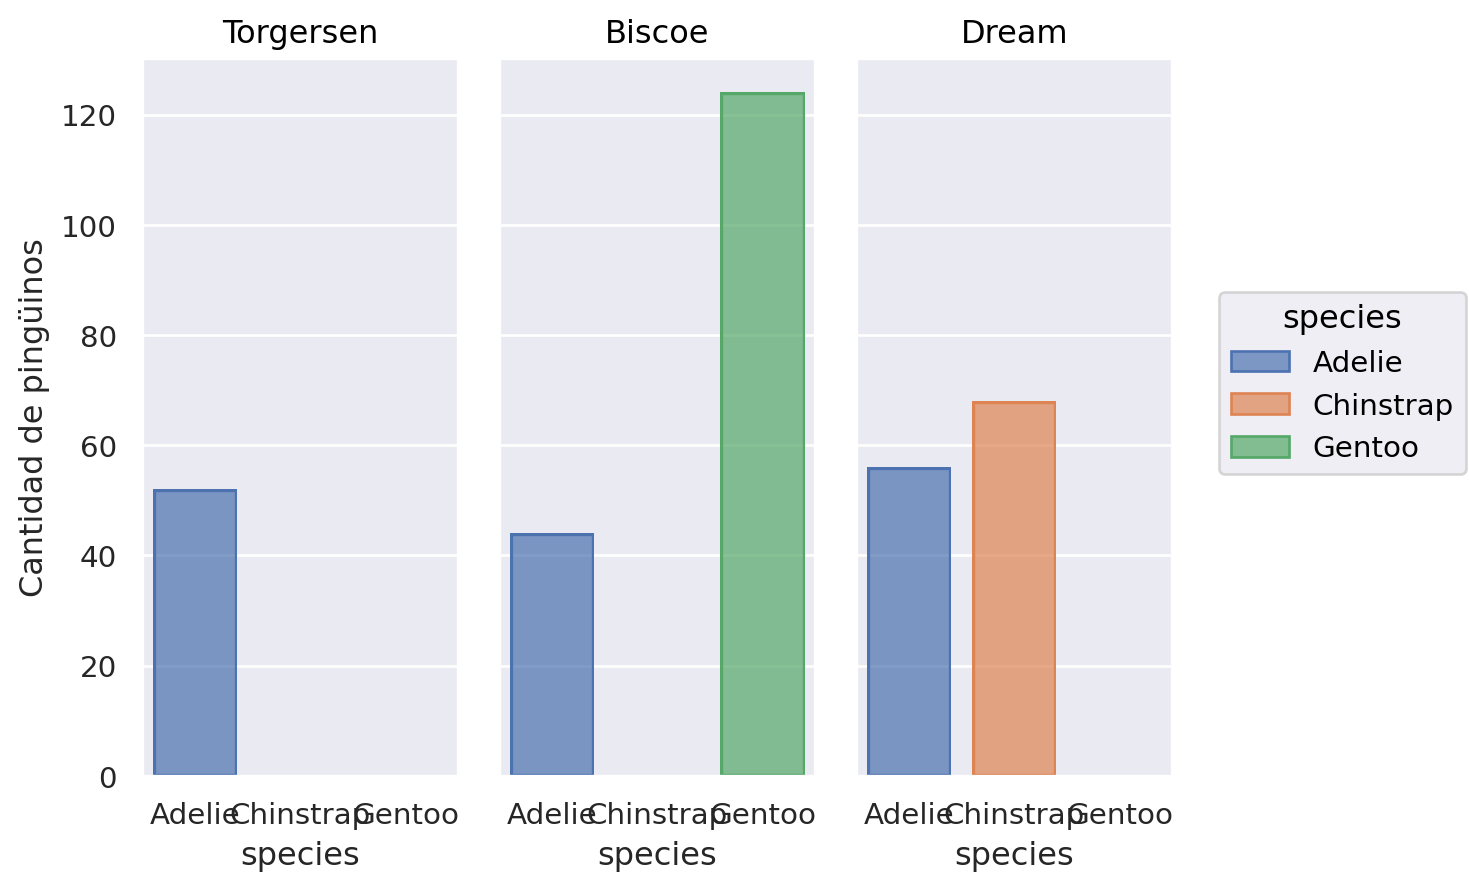

In [117]:
(
    so.Plot(data = penguins, x = 'species')
    .add(so.Bar(),so.Hist(),color ='species')
    .facet("island",wrap=3)
        .label(
        y="Cantidad de pingüinos",
    )
)

### Ejercicio 7
Realizar un histograma de la cantidad de pinguinos en función del tamaó del ala( variable flipper_length_mm). A partir del gráfico, estimar el valor mínimo , máximo, la media y la mediana. Luego verificar sus estimaciones utilizando los comandos apropiados

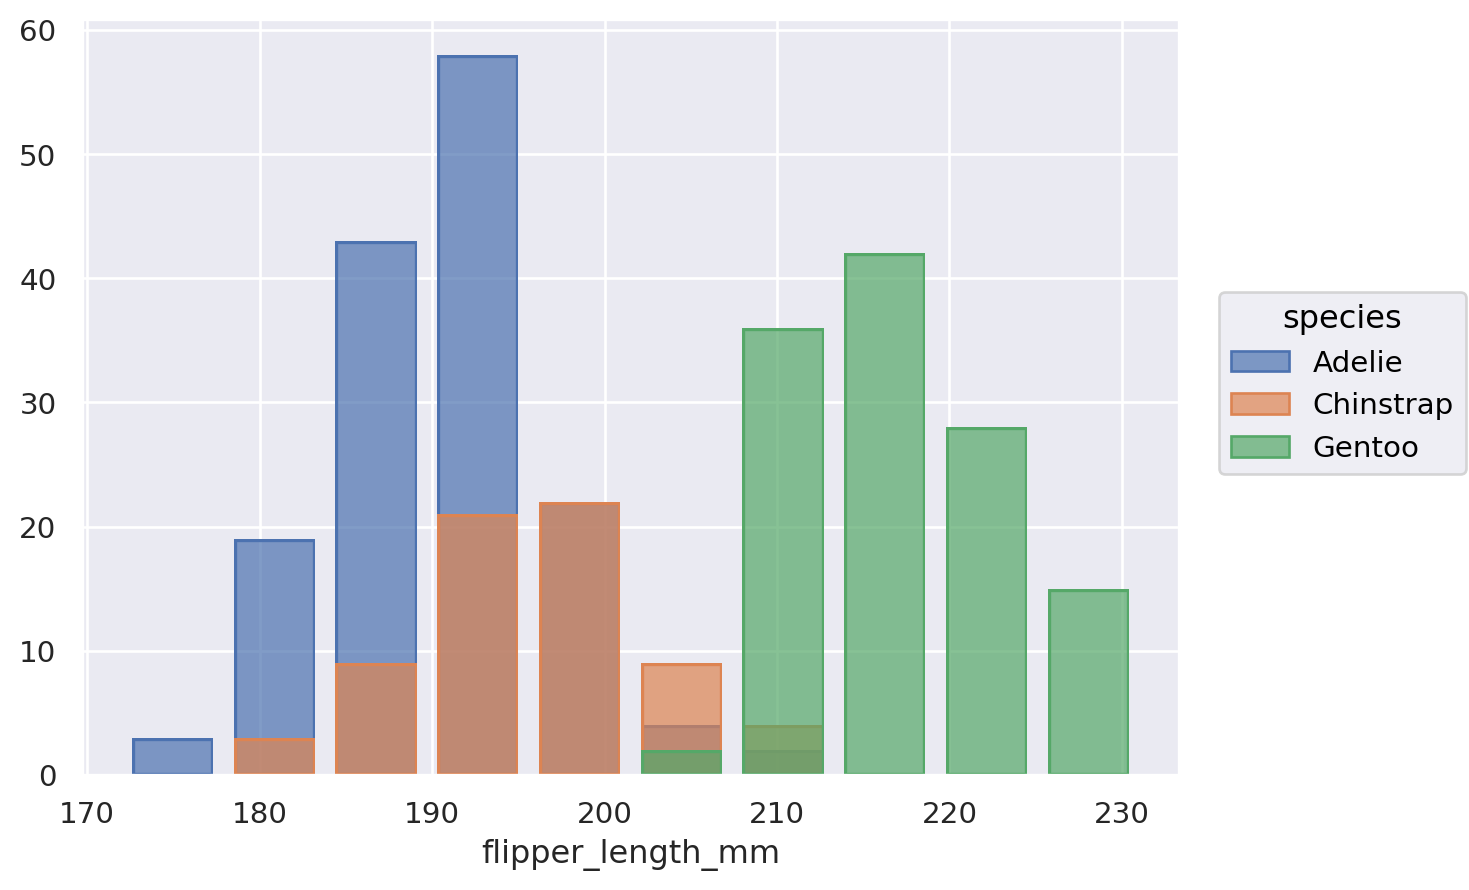

In [119]:
(
    so.Plot(data = penguins, x = 'flipper_length_mm')
    .add(so.Bar(),so.Hist(),color='species')
)

Mis estimaciones son:

Mínimo : 170mm

Máximo: 230mm

Media : 170mm

Mediana: 200mm

In [126]:
penguins['flipper_length_mm'].max()

np.float64(231.0)

In [127]:
penguins['flipper_length_mm'].min()

np.float64(172.0)

In [128]:
penguins['flipper_length_mm'].mean()

np.float64(200.91520467836258)

In [129]:
penguins['flipper_length_mm'].median()

np.float64(197.0)

### Ejercicio 8
(a)Calcular lo mismo para la variable bill_depth_mm

In [131]:
penguins['bill_depth_mm'].max()
penguins['bill_depth_mm'].min()
penguins['bill_depth_mm'].mean()
penguins['bill_depth_mm'].median()

# El valor máximo de bill_depth_mm es 21.5 mm, el valor mínimo es 13.1 mm, el valor medio es 17.15 mm y el valor mediano es 17.3 mm.

np.float64(17.3)

(b)Según lo observado en el ejercicio 4 ¿Esos valores varían según la especie? ¿Cómo podemos usar gráficos BoxPlot para ver la relación entre species y bill_depth_mm?

<Axes: xlabel='species', ylabel='bill_depth_mm'>

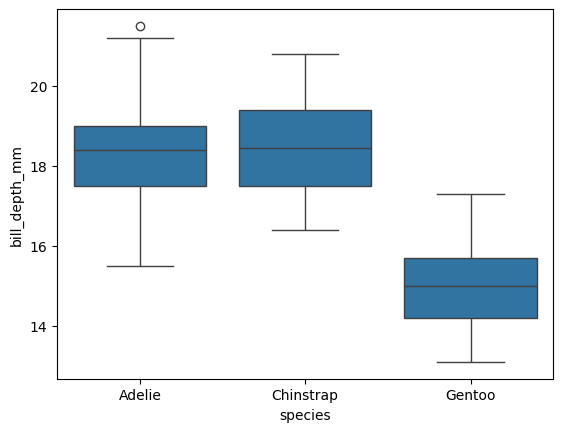

In [134]:
sns.boxplot(data=penguins, x='species', y='bill_depth_mm')

### Ejercicio 9
(a) Rehacer el scatter plot del Ejercicio 4, modificando el tamaño de los puntos según el peso de cada pinguino, utilizando el parámetro pointsize ¿Qué se observa?

(b) En base a lo observado, ¿Cuál es la especie con mayor peso? Verificarlo mediante alguna visualización.

<Axes: xlabel='bill_depth_mm', ylabel='bill_length_mm'>

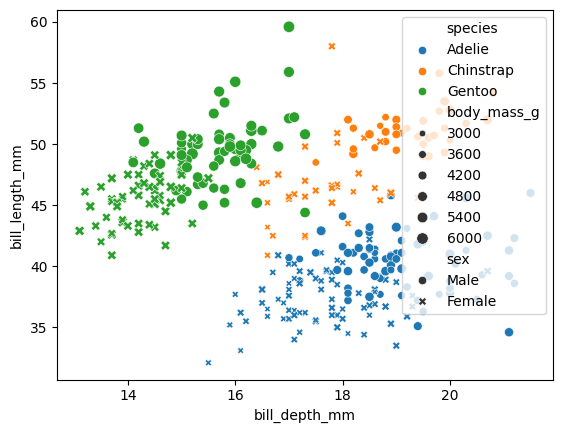

In [137]:
#hacer que los puntos del gráfico de dispersión tengan un tamaño proporcional a la masa corporal de los pingüinos, se puede usar el parámetro "size" en la función scatterplot de seaborn. El código sería el siguiente:

sns.scatterplot(data = penguins, x="bill_depth_mm", y="bill_length_mm", hue="species",style="sex",size = 'body_mass_g')

En base a lo observado la especie con mayor peso está entre Chinstrap y Gentoo. Se podría visualizar bien haciendo un histograma maybe.

### Ejercicio 10
Tenes datos de una encuesta realizada en distintas provincias de Argentina y queres saber
cuantas personas respondieron a la encuesta en cada provincia. ¿Haces un grafico de lıneas, de dispersion (scatter), histograma o un grafico de barras (bar plot)? Hace a mano en tu cuaderno como esperas que se vea el grafico.

Para mí lo mejor sería hacer un gráfico de barras, ya que un histograma es para variables numéricas continuas, un gráfico de dispersión no tendría mucho sentido y un gráfico de líneas tampoco (en el mejor de los casos sería igual de descriptivo que uno de barras).

### Ejercicio 11
 Estás estudiando la relación entre altura y peso de las personas. Tenés un data-set que tiene como variables la edad, sexo y peso de cada persona. Si querés describir estas variables por separado, ¿qué gráfico harías para cada una? ¿y si querés visualizar la relación entre peso y altura? Hacé a mano en tu cuaderno cómo esperás que se vea el gráfico.

Para cada una:
- Edad : Gráfico de barras
- Sexo : Gráfico de barras
- Peso: Histograma (es una variable numérica continua)

¿Para visualizar la relación entre peso y altura?
Acá podría ir un scatterplot porque son dos variables numéricas continuas I guess.

### Ejercicio 12
Hacer un gráfico de barras que muestre la cantidad de países que hay en cada continente según los datos de gapminder, de las siguientes dos formas distintas:
(a) Calculando primero las cantidades y llamando a .add(so.Bar()).
(b) Utilizando so.hist() para calcular las cantidades

In [144]:
gapminder

,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106
...,...,...,...,...,...,...
1699,Zimbabwe,1987,9216418.0,Africa,62.351,706.157306
1700,Zimbabwe,1992,10704340.0,Africa,60.377,693.420786
1701,Zimbabwe,1997,11404948.0,Africa,46.809,792.449960
1702,Zimbabwe,2002,11926563.0,Africa,39.989,672.038623


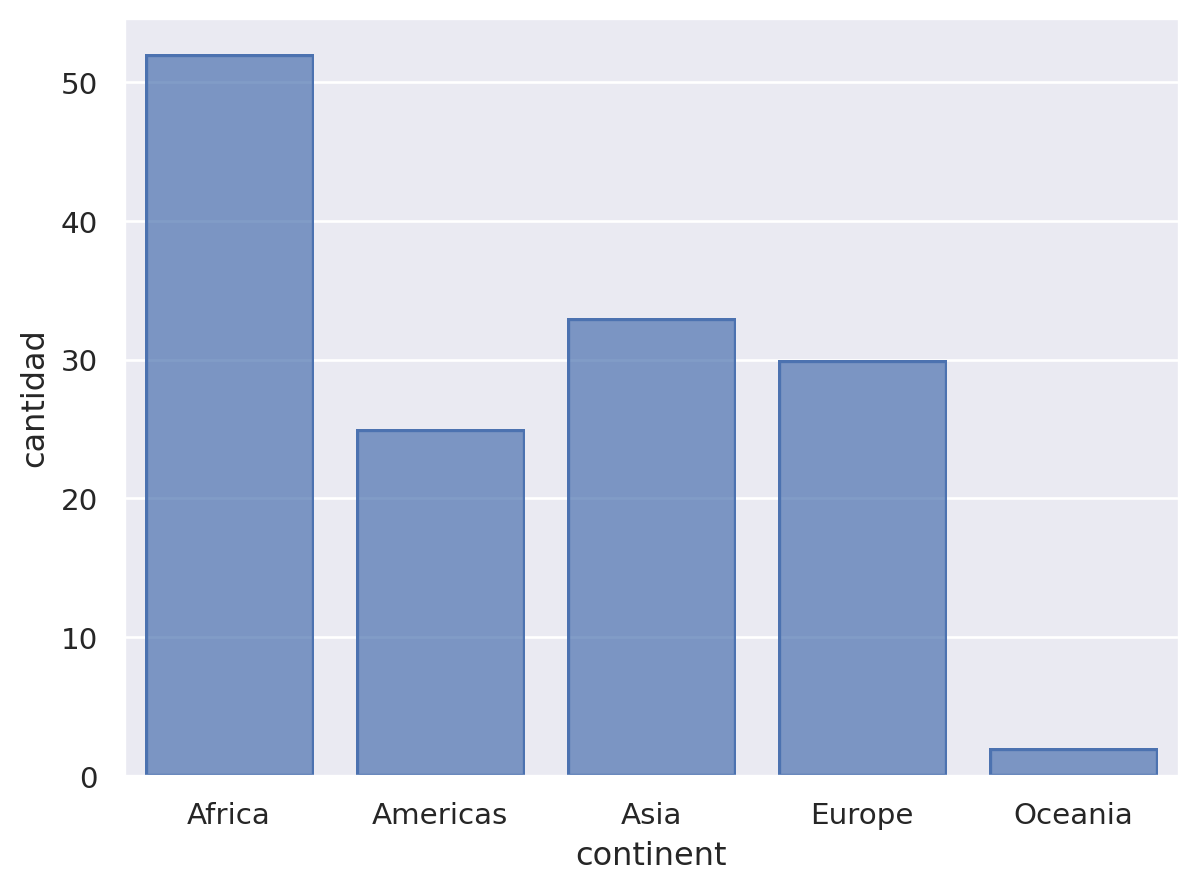

In [ ]:
conteo = gapminder.groupby('continent')["country"].nunique().reset_index(name='cantidad')
(
    so.Plot(data = conteo, x = 'continent', y = 'cantidad')
    .add(so.Bar())
)

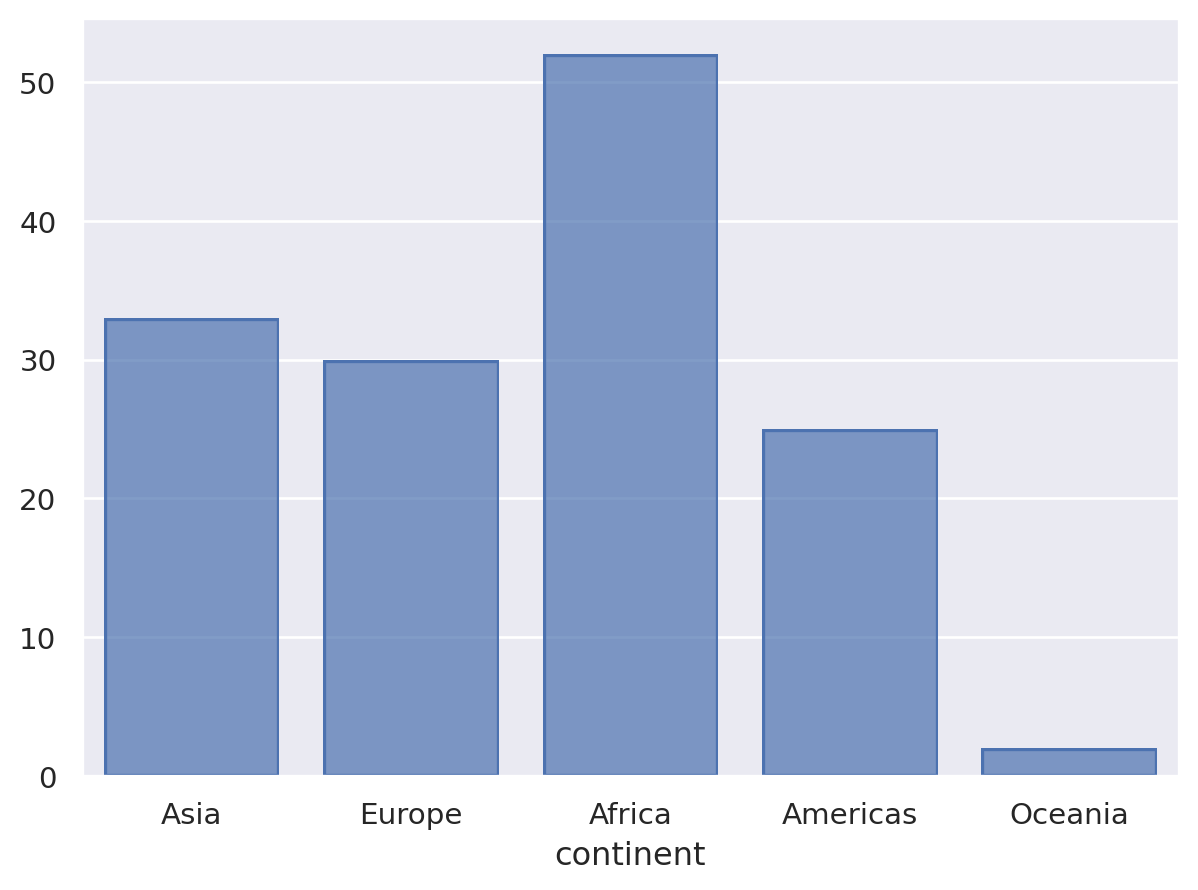

In [151]:
paises_unicos = gapminder[["continent", "country"]].drop_duplicates()

(
    so.Plot(data=paises_unicos, x="continent")
    .add(so.Bar(), so.Hist())
)

### Ejercicio 13
Querés investigar cómo varía la expectativa de vida entre los continentes. Para eso necesitás un gráfico como el siguiente:

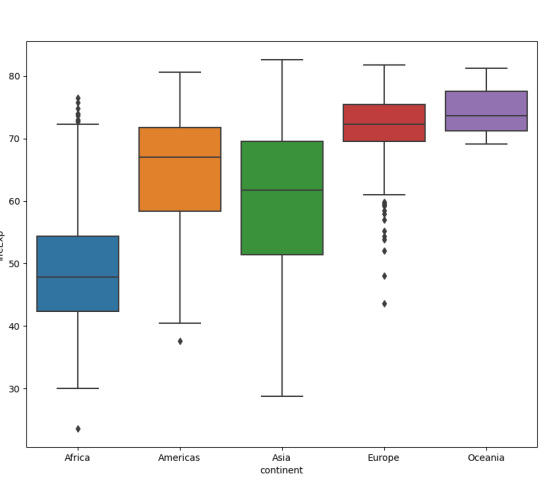

Reproducí el gráfico de arriba reemplazando adecuadamente lo que falta en el siguiente código:

<Axes: xlabel='continent', ylabel='lifeExp'>

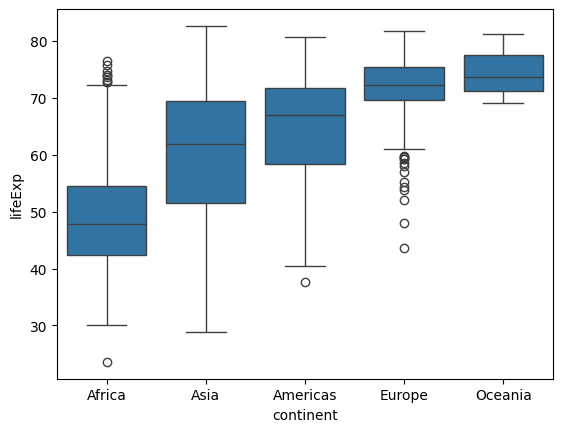

In [152]:
sns.boxplot(gapminder,x ='continent',y = 'lifeExp',
            order=sorted(gapminder['continent'].unique(), key=lambda x: gapminder[gapminder['continent'] == x]['lifeExp'].mean()))

Ah pero que distinguido